# Getting Started with KerasHub: Vision, LLMs, and Transfer Learning

**Author:** Juan Guillermo Gomez  
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jggomez/workshop-open-models/blob/main/session-01-hf-kerashub-litert/01-kerashub-image-classification/Keras_Hub.ipynb)

---

## Overview

**KerasHub** is the official high-level natural language processing and computer vision modeling library built on top of **Keras 3**. It offers unified, production-grade access to modern deep learning architectures with pre-trained weights from Google, Hugging Face, and Kaggle.

### Core Architectural Principles
KerasHub models are built upon three decoupled, modular abstractions:
1. **Backbone:** The neural network feature extractor (e.g., ResNet, MobileNet, Gemma) that converts raw input representations into dense hidden states.
2. **Preprocessor:** The deterministic data transformation pipeline that handles tokenization, resizing, pixel normalization, and batch tensor collation.
3. **Task Classifier / Head:** The end-to-end task-specific model (e.g., `ImageClassifier`, `CausalLM`) combining the preprocessor, backbone, and final projection layers.

### Workshop Roadmap
In this comprehensive hands-on guide, we explore:
- **Part 1: Multi-Backend Setup:** Configuring Keras 3 with the JAX backend for high-performance XLA compilation.
- **Part 2: Computer Vision:** Zero-shot image classification using pre-trained `ResNet-50` on ImageNet-1k, exploring modular backbones and preprocessors.
- **Part 3: Large Language Models (LLMs):** Text generation with Google's `Gemma 3 1B` causal language model, comparing greedy vs stochastic Top-K sampling with temperature scaling.
- **Part 4: Transfer Learning & Model Publishing:** End-to-end fine-tuning on the Microsoft Cats vs Dogs dataset, pipeline data augmentation, local preset export, and publishing to the Kaggle Model Hub.


In [ ]:
!pip install --upgrade --quiet keras-hub keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.9/947.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.22.2 which is incompatible.


## Part 1: Environment Setup & Multi-Backend Configuration

Keras 3 decouples high-level model definitions from the low-level numerical engine. You can run the exact same code interchangeably across:
- **JAX (`KERAS_BACKEND="jax"`):** Compiles operations with XLA (Accelerated Linear Algebra) for industry-leading throughput on GPUs and TPUs.
- **PyTorch (`KERAS_BACKEND="torch"`):** Native dynamic execution and debugging.
- **TensorFlow (`KERAS_BACKEND="tensorflow"`):** Production serving and TensorFlow ecosystem integrations.

In this guide, we use **JAX** as our compute engine and configure memory allocation:


In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"  # or "tensorflow" or "torch"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"

289881/289881 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


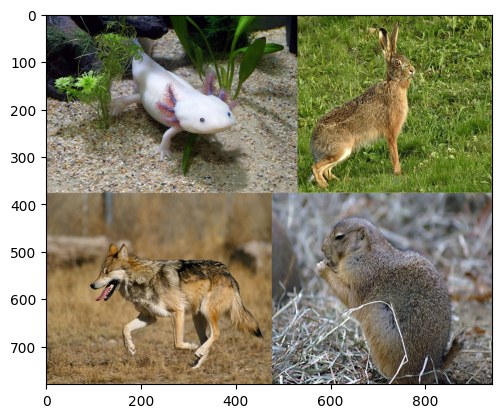

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt

image_url = "https://storage.googleapis.com/questionsanswersproject/animales_mexico.jpeg"
image_path = keras.utils.get_file(origin=image_url)
image = keras.utils.load_img(image_path)
plt.imshow(image)

## Part 2: Computer Vision with Pre-trained ResNet-50

KerasHub provides pre-trained vision models via **Presets**. A preset bundles:
1. The exact network architecture (e.g., ResNet-50 with 50 convolutional and residual bottleneck layers).
2. The pre-trained weights learned on ImageNet-1k (1.4 million labeled images across 1,000 object categories).
3. The matching preprocessor configured for 224x224 input resolution and ImageNet normalization statistics.

We load the classifier preset using `keras_hub.models.ImageClassifier.from_preset("resnet_50_imagenet")`:


In [ ]:
import keras_hub

image_classifier = keras_hub.models.ImageClassifier.from_preset(
    "resnet_50_imagenet",
    activation="softmax",
)
batch = np.array([image])
image_classifier.preprocessor.image_size = (224, 224)
preds = image_classifier.predict(batch)
preds.shape

100%|██████████| 841/841 [00:00<00:00, 1.58MB/s]


100%|██████████| 3.59k/3.59k [00:00<00:00, 7.89MB/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(1, 1000)

### Decoding Predictions to Human-Readable Classes

The raw output of `image_classifier.predict()` is a tensor of softmax probabilities over the 1,000 ImageNet classes. We use the built-in utility `keras_hub.utils.decode_imagenet_predictions()` to map top probabilities to human-readable WordNet class names:


In [ ]:
keras_hub.utils.decode_imagenet_predictions(preds)

[[('hare', 0.9521790742874146),
  ('axolotl', 0.03367036208510399),
  ('coyote', 0.006725258659571409),
  ('timber_wolf', 0.001643919968046248),
  ('marmot', 0.0006301653338596225)]]

### Deconstructing the KerasHub Model Architecture

One of KerasHub's most powerful architectural features is modular decomposition. We can access and inspect individual components:
- `image_classifier.preprocessor`: Takes raw arbitrary-sized image batches, resizes them to 224x224, and applies ImageNet normalization.
- `image_classifier.backbone`: Takes preprocessed tensors and extracts rich spatial feature maps of shape `[batch, 7, 7, 2048]`.
- `image_classifier.summary()`: Displays the complete layer topology, parameter counts, and trainable status.


In [ ]:
print("Raw input shape:", batch.shape)
resized_batch = image_classifier.preprocessor(batch)
print("Preprocessed input shape:", resized_batch.shape)
hidden_states = image_classifier.backbone(resized_batch)
print("Latent space shape:", hidden_states.shape)

Raw input shape: (1, 780, 940, 3)
Preprocessed input shape: (1, 224, 224, 3)
Latent space shape: (1, 7, 7, 2048)


In [ ]:
image_classifier.summary()

Preprocessor: "res_net_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ res_net_image_converter (ResNetImageConverter)                │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "res_net_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                      │ (None, None, None, 3)              │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ res_net_backbone (ResNetBackbone)             │ (None, None, None, 2048)           │          23,561,152 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ pooler (GlobalAveragePooling2D)               │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 2048)                       │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 1000)                       │           2,049,000 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 25,610,152 (97.69 MB)

 Trainable params: 25,557,032 (97.49 MB)

 Non-trainable params: 53,120 (207.50 KB)

---

## Part 3: Text Generation with Large Language Models (Gemma 3)

KerasHub provides pre-trained causal language models via the `CausalLM` family of classes. Here, we load **Gemma 3 1B** (`gemma3_1b`), a compact, high-efficiency open-weights model developed by Google DeepMind.

Key advantages:
- **1 Billion Parameters:** Fits comfortably in standard GPU memory (and CPU) while delivering strong reasoning and generation capabilities.
- **Unified CausalLM API:** Exposes `.generate()`, `.compile(sampler=...)`, `.score()`, and direct access to `preprocessor.tokenizer`.


In [ ]:
gemma_lm = keras_hub.models.Gemma3CausalLM.from_preset("gemma3_1b")

In [ ]:
gemma_lm.generate("Keras is a", max_length=30)

'Keras is a deep learning library for Python. It is a high-level API for neural networks. It is a Python library for deep learning'

### Batched Generation for High-Throughput Inference

KerasHub language models support list-of-strings inputs to generate completions for multiple prompts in parallel with dynamic padding:


In [ ]:
# Generate with batched prompts.
gemma_lm.generate(["Keras is a", "I want to say"], max_length=30)

['Keras is a deep learning library for Python. It is a high-level API for neural networks. It is a Python library for deep learning',
 'I want to say that I am very happy with the service I received from the staff at the hotel. The staff was very friendly and helpful.']

### Controlling Generation with Advanced Samplers (Top-K & Temperature)

By default, `.generate()` uses greedy search (deterministic argmax). To introduce creativity and diversity:
- **Top-K Sampling (`TopKSampler(k=10)`):** Truncates candidate token distribution to only the top 10 most probable tokens at each step.
- **Temperature (`temperature=2.0`):** Flattens the probability distribution. Higher values (>1.0) increase diversity and novelty, while lower values (<1.0) make responses more focused and deterministic.


In [ ]:
gemma_lm.compile(sampler=keras_hub.samplers.TopKSampler(k=10, temperature=2.0))
gemma_lm.generate("como se hace la bandeja paisa?",)

'como se hace la bandeja paisa?\nsi alguien quiere aprender como hacerse una la pias de las imagenes de este blog se podrian dar de un par?\n\nhola me gustaría tener más informacion para crear mis propios dibujos de los que ya tengo\nes que quiero saber como se hace una imagen para el blog, porque la verdad que no tengo mucha experiencia, pero quisiera aprender.\nhola soy nuevo en este blog, me interesa crear dibujos, ya he hecho varios y me gustan mucho los tuyos, por eso quiero pedirles ayuda para aprender a realizar un dibujo y saber hacer un modelo para que pueda copiarlo y hacerlo en mi propio blog, espero su ayuda, gracias de antemano!!'

### Model Architecture & Parameter Inspection

We inspect the full layer specification, attention heads, and hidden dimensions of the Gemma 3 model:


In [ ]:
gemma_lm.summary()

Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 1152)        │     999,885,952 │ padding_mask[0][0],        │
│ (Gemma3Backbone)              │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     301,989,888 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 999,885,952 (3.72 GB)

 Trainable params: 999,885,952 (3.72 GB)

 Non-trainable params: 0 (0.00 B)

### Subword Tokenization with the Gemma Tokenizer

Language models operate on numerical token IDs, not raw text. We can directly access the model's subword tokenizer to inspect tokenization and detokenization:


In [ ]:
tokenizer = gemma_lm.preprocessor.tokenizer
tokens_ids = tokenizer.tokenize("como se hace la bandeja paisa?")
print(tokens_ids)
string = tokenizer.detokenize(tokens_ids)
print(string)

[ 58603    636  17949    759 194647  39270 236746 236881]
como se hace la bandeja paisa?


### Memory Management: Releasing Model Weights

Before proceeding to fine-tuning vision models in the next section, we delete the language model instance to release GPU/accelerator memory:


In [ ]:
del gemma_lm

---

## Part 4: Transfer Learning: Fine-Tuning and Publishing an Image Classifier

In this section, we adapt a pre-trained `ResNet-50` backbone to a new downstream task: binary classification between **Cats and Dogs** using the Microsoft Cats vs Dogs dataset.

### The Transfer Learning Workflow
1. **Data Ingestion & Cleaning:** Download the dataset and filter out corrupted or truncated image files.
2. **Dataset Pipeline:** Split into training (80%) and validation (20%) subsets with batching.
3. **Data Augmentation:** Apply pixel rescaling (`1.0 / 255`), horizontal flipping, and random cropping to prevent overfitting.
4. **Task Head Adaptation:** Reinitialize the final classification head with `num_classes=2` and softmax activation.
5. **Training:** Compile with Adam optimizer and train for 3 epochs.
6. **Local Preset Export:** Save the complete model and preprocessor configuration using `save_to_preset()`.
7. **Publishing to Kaggle:** Upload the trained model to the Kaggle Model Hub for community sharing and production reuse.


In [ ]:
import pathlib

extract_dir = keras.utils.get_file(
    "cats_vs_dogs",
    "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip",
    extract=True,
)
data_dir = pathlib.Path(extract_dir) / "PetImages"

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Filtering Corrupted Images

Real-world datasets often contain truncated or unreadable image headers. We inspect the raw bytes of each image file to ensure valid EXIF/JFIF headers before constructing the dataset:


In [ ]:
num_skipped = 0

for path in data_dir.rglob("*.jpg"):
    with open(path, "rb") as file:
        is_jfif = b"JFIF" in file.peek(10)
    if not is_jfif:
        num_skipped += 1
        os.remove(path)

print(f"Deleted {num_skipped} images.")

Deleted 1590 images.


### Constructing Training and Validation Datasets

We use `keras.utils.image_dataset_from_directory` to load images from disk with an 80/20 train/validation split:


In [ ]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(256, 256),
    batch_size=32,
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Using 4682 files for validation.


### Data Augmentation & Preprocessing Pipeline

We assemble a `keras.layers.Pipeline` to apply pixel rescaling (`1.0 / 255`), random horizontal flips, and random crops:


In [ ]:
preprocessor = keras.layers.Pipeline(
    [
        keras.layers.Rescaling(1.0 / 255),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.2),
    ]
)

### Adapting the ResNet-50 Classifier Head

By setting `num_classes=2` and `activation="softmax"`, KerasHub retains the pre-trained ResNet-50 feature extraction backbone and attaches a newly initialized 2-class projection head:


In [ ]:
image_classifier = keras_hub.models.ImageClassifier.from_preset(
    "resnet_50_imagenet",
    activation="softmax",
    num_classes=2,
    preprocessor=preprocessor,
)

### Compiling the Model with Optimizer and Loss Function

We compile the adapted classifier using the Adam optimizer with a conservative learning rate (`1e-4`) and `sparse_categorical_crossentropy`:


In [ ]:
image_classifier.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

### Model Training on the Cats vs Dogs Dataset

We train the model for 3 epochs while tracking validation accuracy:


In [ ]:
image_classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
)

Epoch 1/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 110s 140ms/step - accuracy: 0.9593 - loss: 0.1313 - val_accuracy: 0.9897 - val_loss: 0.0319
Epoch 2/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.9877 - loss: 0.0345 - val_accuracy: 0.9921 - val_loss: 0.0217
Epoch 3/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.9907 - loss: 0.0273 - val_accuracy: 0.9930 - val_loss: 0.0204


### Exporting the Fine-Tuned Model as a KerasHub Preset

`save_to_preset()` serializes the trained weights, the model architecture, and the preprocessor into a self-contained local preset directory:


In [ ]:
image_classifier.save_to_preset("cats_vs_dogs")

### Evaluating Predictions on a Sample Test Image

We load a sample test image from the dataset and visualize it:


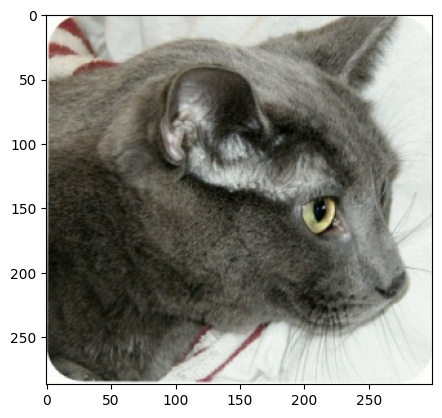

In [ ]:
image = keras.utils.load_img(data_dir / "Cat" / "6779.jpg")
plt.imshow(image)

### Publishing the Trained Preset to Kaggle Model Hub

We retrieve Kaggle credentials from Google Colab secrets (`userdata`) and publish the model preset using `keras_hub.upload_preset()`:


In [ ]:
from google.colab import userdata

username = userdata.get("KAGGLE_USERNAME")
keras_hub.upload_preset(
    f"kaggle://{username}/resnet/keras/cats_vs_dogs",
    "cats_vs_dogs",
)

Uploading Model https://www.kaggle.com/models/jggomezt/resnet/keras/cats_vs_dogs ...
Model 'resnet' does not exist or access is forbidden for user 'jggomezt'. Creating or handling Model...
Model 'resnet' Created.
Starting upload for file cats_vs_dogs/metadata.json


Uploading: 100%|██████████| 190/190 [00:00<00:00, 469B/s]

Upload successful: cats_vs_dogs/metadata.json (190B)
Starting upload for file cats_vs_dogs/model.weights.h5



Uploading: 100%|██████████| 94.7M/94.7M [00:01<00:00, 82.4MB/s]

Upload successful: cats_vs_dogs/model.weights.h5 (90MB)
Starting upload for file cats_vs_dogs/task.weights.h5


...


Uploading: 100%|██████████| 2.77k/2.77k [00:00<00:00, 7.46kB/s]

Upload successful: cats_vs_dogs/preprocessor.json (3KB)
Starting upload for file cats_vs_dogs/task.json



Uploading: 100%|██████████| 4.98k/4.98k [00:00<00:00, 13.1kB/s]

Upload successful: cats_vs_dogs/task.json (5KB)


Your model instance has been created.
Files are being processed...
See at: https://www.kaggle.com/models/jggomezt/resnet/keras/cats_vs_dogs


### Loading and Verifying the Published Preset from Kaggle Hub

We verify that the preset can be loaded directly from Kaggle Hub (`kaggle://<username>/resnet/keras/cats_vs_dogs`) and run inference:


In [ ]:
image_classifier = keras_hub.models.ImageClassifier.from_preset(
    f"kaggle://{username}/resnet/keras/cats_vs_dogs",
)
print(image_classifier.predict(np.array([image])))

100%|██████████| 841/841 [00:00<00:00, 2.14MB/s]


100%|██████████| 4.86k/4.86k [00:00<00:00, 10.4MB/s]


100%|██████████| 270M/270M [00:03<00:00, 82.6MB/s]
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 324 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


100%|██████████| 90.3M/90.3M [00:01<00:00, 71.2MB/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[9.9920583e-01 7.9413876e-04]]


### Final Memory Cleanup

Release the model instance from accelerator memory:


In [ ]:
del image_classifier